In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay, f1_score, PrecisionRecallDisplay,
    precision_score, recall_score
)

In [22]:
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape}  , Test: {X_test.shape}')
print(f'Positive rate: {y_train.mean():.3f}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

Train: (55989, 89)  |  Test: (13998, 89)
Positive rate: 0.090
scale_pos_weight: 10.1


In [23]:
from sklearn.feature_selection import SelectFromModel

# Use XGBoost's own feature importances to select features
selector_xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
selector = SelectFromModel(selector_xgb, threshold="mean")
selector.fit(X_train, y_train)

top_features = X_train.columns[selector.get_support()].tolist()
X_train = X_train[top_features]
X_test  = X_test[top_features]

print(f"Using {len(top_features)} features: {top_features}")

Using 44 features: ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'glipizide', 'glyburide', 'rosiglitazone', 'insulin', 'diabetesMed', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'race_Unknown', 'max_glu_serum_None', 'A1Cresult_>8', 'A1Cresult_None', 'A1Cresult_Norm', 'admission_type_id_2', 'admission_type_id_3', 'admission_type_id_5', 'admission_type_id_6', 'discharge_disposition_id_2', 'discharge_disposition_id_3', 'discharge_disposition_id_4', 'discharge_disposition_id_5', 'discharge_disposition_id_6', 'discharge_disposition_id_7', 'discharge_disposition_id_15', 'discharge_disposition_id_18', 'discharge_disposition_id_22', 'discharge_disposition_id_23', 'discharge_disposition_id_25', 'discharge_disposition_id_28', 'admission_source_id_3', 'admission_source_id_4', 'admission_source_id_5', 'admission_source_id_6', 'admission_source_id_7', 'admission_source_id_1

## Hyperparameter Search

In [24]:
param_dist = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    xgb,
    param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print(f'\nBest CV ROC-AUC: {search.best_score_:.4f}')
print('Best params:', search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV ROC-AUC: 0.6475
Best params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}


## Evaluation

In [25]:
model = search.best_estimator_
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_pred      = model.predict(X_test)

print('Default threshold (0.5):')
print(classification_report(y_test, y_pred, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

Default threshold (0.5):
                precision    recall  f1-score   support

Not Readmitted       0.94      0.70      0.80     12741
Readmitted <30       0.14      0.51      0.22      1257

      accuracy                           0.68     13998
     macro avg       0.54      0.60      0.51     13998
  weighted avg       0.86      0.68      0.75     13998

ROC-AUC: 0.6496


In [26]:
# sweep thresholds to maximize minority class F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_pred_prob >= t).astype(int), pos_label=1, zero_division=0)
              for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
y_pred_best = (y_pred_prob >= best_thresh).astype(int)

print(f'Optimal threshold: {best_thresh:.2f}')
print(classification_report(y_test, y_pred_best, target_names=['Not Readmitted', 'Readmitted <30']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')

Optimal threshold: 0.61
                precision    recall  f1-score   support

Not Readmitted       0.93      0.90      0.92     12741
Readmitted <30       0.22      0.27      0.24      1257

      accuracy                           0.85     13998
     macro avg       0.57      0.59      0.58     13998
  weighted avg       0.86      0.85      0.85     13998

ROC-AUC: 0.6496


## Confusion Matrix

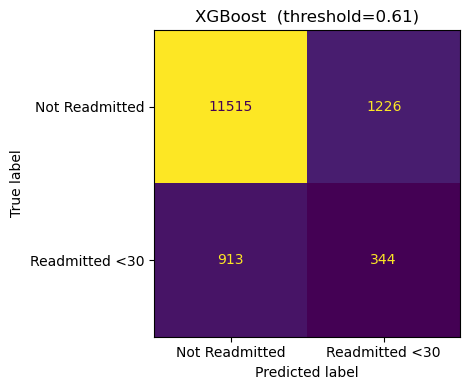

In [27]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=['Not Readmitted', 'Readmitted <30']
).plot(ax=ax, colorbar=False)
ax.set_title(f'XGBoost  (threshold={best_thresh:.2f})')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png', dpi=150)
plt.show()

## ROC & Precision-Recall Curves

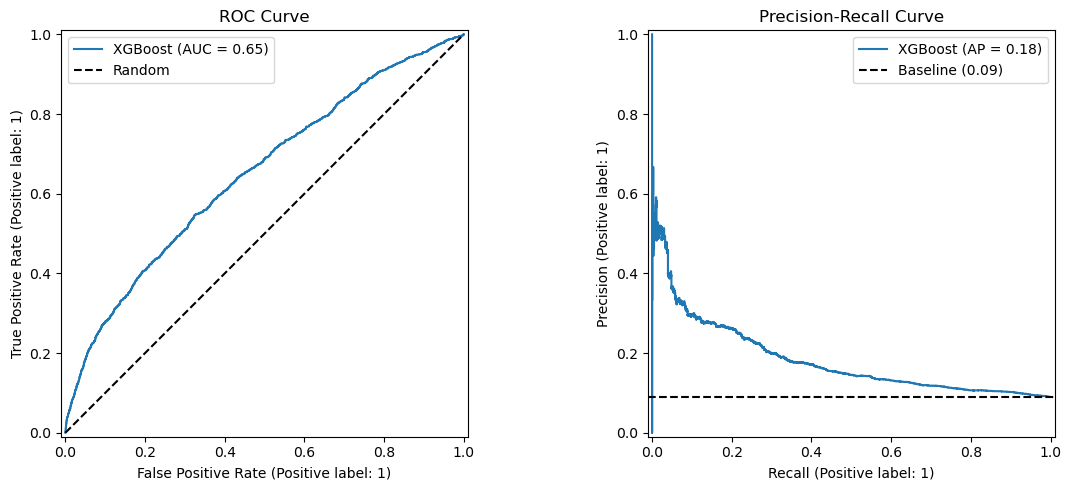

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_pred_prob, ax=axes[0], name='XGBoost')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_title('ROC Curve')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob, ax=axes[1], name='XGBoost')
axes[1].axhline(y_test.mean(), color='k', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[1].legend()
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('roc_pr_xgb.png', dpi=150)
plt.show()

## Feature Importance

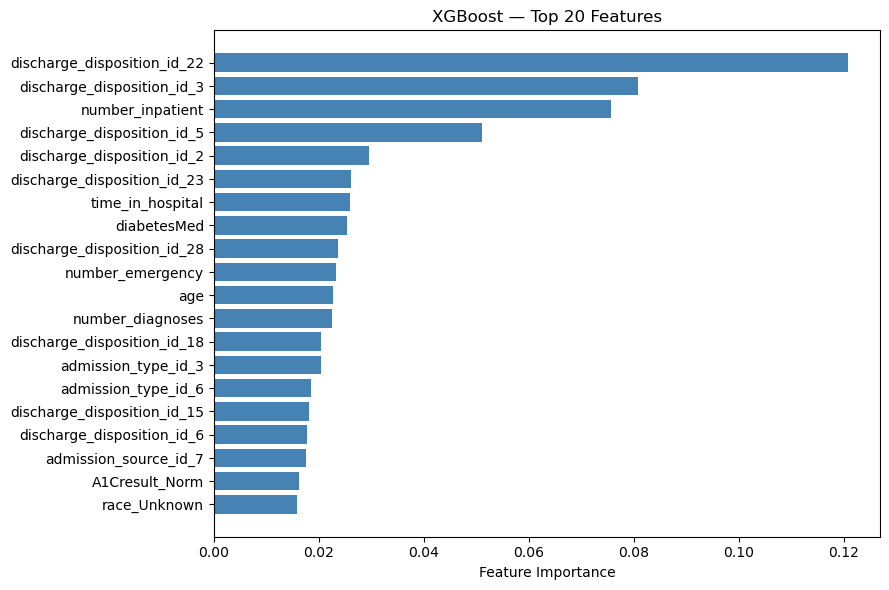

In [29]:
imp_df = (
    pd.DataFrame({'feature': X_train.columns, 'importance': model.feature_importances_})
    .sort_values('importance', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost — Top 20 Features')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150)
plt.show()

## Model Summary

In [30]:
summary = pd.DataFrame({
    'Metric': ['ROC-AUC', 'Precision (minority)', 'Recall (minority)', 'F1 (minority)', 'Macro F1'],
    'Value': [
        round(roc_auc_score(y_test, y_pred_prob), 4),
        round(precision_score(y_test, y_pred_best, pos_label=1, zero_division=0), 3),
        round(recall_score(y_test, y_pred_best), 3),
        round(f1_score(y_test, y_pred_best, pos_label=1, zero_division=0), 3),
        round(f1_score(y_test, y_pred_best, average='macro', zero_division=0), 3),
    ]
})
print(summary.to_string(index=False))

              Metric  Value
             ROC-AUC 0.6496
Precision (minority) 0.2190
   Recall (minority) 0.2740
       F1 (minority) 0.2430
            Macro F1 0.5790
